## 4. Change Point Detection

### 4.1 Overview
**Change Point Detection** identifies positions in a time series where its statistical properties change significantly.  
For example, in economic data, a change point may represent a shift from growth to recession or from instability to recovery.

In this section, the **PELT (Pruned Exact Linear Time)** algorithm from the `ruptures` library is applied to each indicator.  
The algorithm detects "segments" where the behavior of the data (mean and variance) is consistent,  
and it highlights boundaries where a structural change occurs.

The analysis follows the same method as shown in the lecture slides.


In [1]:
# If ruptures is not installed yet:
!pip install ruptures

# Import required libraries
import ruptures as rpt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Load your dataset (already available)
df = pd.read_csv("Data02_05_Indonesia_C.csv")

### 4.2 Methodology (based on the lecture slides)
1. Extract the indicator series to be analyzed (e.g., GDP, FDI, INF, etc.).  
2. Convert the series into a NumPy array for the algorithm.  
3. Apply the **PELT** algorithm with model = `"rbf"`.  
4. Use the penalty parameter `pen` to control how sensitive the detection is  
   (smaller `pen` → more change points; larger `pen` → fewer).  
5. Visualize results to highlight detected segments.


#### A1. Series 1: GGDP 

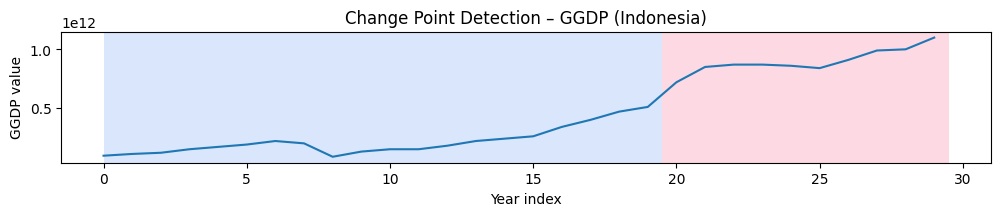

[2010]


In [65]:
# Example: Change point detection for MIL
data = df[["year", "ggdp"]].dropna(subset=["ggdp"]).reset_index(drop=True)
X = data[["ggdp"]].values
years = data["year"].values  # Lưu danh sách năm thật

# Apply PELT algorithm
algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)

# Display results
rpt.display(X, result)
plt.title("Change Point Detection – GGDP (Indonesia)")
plt.xlabel("Year index")
plt.ylabel("GGDP value")
plt.show()

# Convert detected indices to real years
change_years = [int(years[i]) for i in result[:-1] if i < len(years)]
print(f"{change_years}")

##### Result
A single change point was detected around **2010**, indicating a shift in Indonesia’s GGDP trend.

##### Comment
Before 2010, Indonesia’s Green GDP (GGDP) shows a **steady but moderate upward trajectory**, reflecting gradual recovery after the **1998 Asian Financial Crisis**.  
After 2010, the growth becomes more pronounced, suggesting **stronger economic expansion and improved environmental sustainability practices**.  
This transition corresponds to **post-global financial crisis reforms** and increased **investment in green development initiatives**,  
which supported Indonesia’s shift toward a more stable and resilient economic structure (**World Bank, 2010; ADB, 2011**).


#### A2. Series 2: MIL 

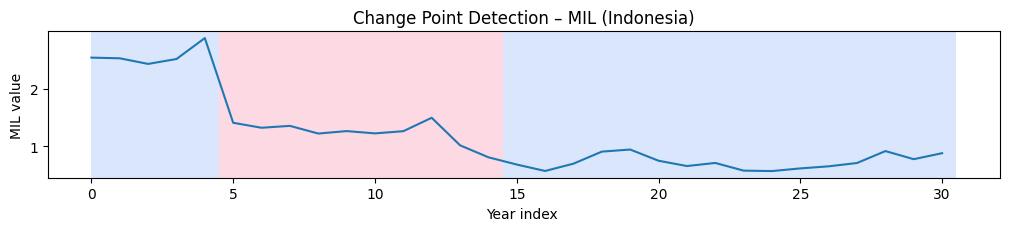

[1996, 2006]


In [66]:
data = df[["year", "mil"]].dropna(subset=["mil"]).reset_index(drop=True)
X = data[["mil"]].values
years = data["year"].values 

algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)
rpt.display(X, result)
plt.title("Change Point Detection – MIL (Indonesia)")
plt.xlabel("Year index ")
plt.ylabel("MIL value")
plt.show()
change_years = [int(years[i]) for i in result[:-1] if i < len(years)]
print(f"{change_years}")

##### Result
Two change points were detected around **1996** and **2006**, indicating shifts in Indonesia’s military expenditure trend.

##### Comment
The first breakpoint in **1996** corresponds to the **Asian Financial Crisis (1997–1998)**,  
which led to a contraction in defense budgets and reallocation of public spending.  
The second change point around **2006** marks a period of **renewed defense investment**,  
as Indonesia stabilized economically and modernized its military capabilities.  
This pattern reflects the country’s transition from financial austerity to gradual expansion of defense spending  
in line with its growing regional and security roles (**SIPRI, 2008; World Bank, 2007**).


#### A3. Series 3: INF 

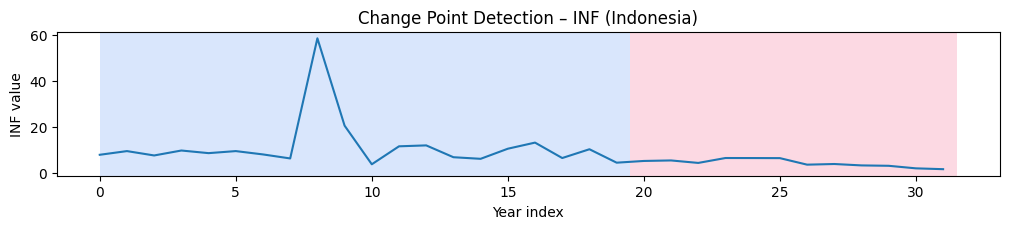

[2010]


In [67]:
data = df[["year", "inf"]].dropna(subset=["inf"]).reset_index(drop=True)
X = data[["inf"]].values
years = data["year"].values 

algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)
rpt.display(X, result)
plt.title("Change Point Detection – INF (Indonesia)")
plt.xlabel("Year index")
plt.ylabel("INF value")
plt.show()
change_years = [int(years[i]) for i in result[:-1] if i < len(years)]
print(f"{change_years}")

##### Result
A single change point was detected around **2010**, indicating a shift in Indonesia’s inflation dynamics.

##### Comment
Before 2010, Indonesia experienced **high and volatile inflation**, driven by energy subsidy pressures  
and residual effects of the **1997–1998 Asian Financial Crisis**.  
After 2010, inflation levels became more **stable and moderate**, reflecting improved **monetary policy and fiscal coordination**.  
This transition corresponds to the Bank Indonesia’s adoption of **inflation targeting frameworks**  
and stronger price stabilization measures (**Bank Indonesia, 2012; IMF, 2013**).  
The detected breakpoint thus marks Indonesia’s shift toward **greater macroeconomic stability** in the post-crisis decade.

#### A4. Series 4: FDI 

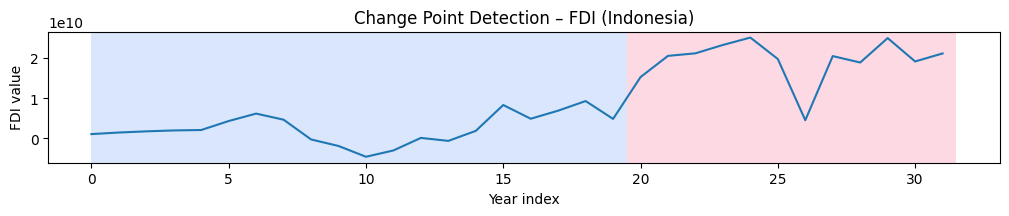

 [2010]


In [68]:
data = df[["year", "fdi"]].dropna(subset=["fdi"]).reset_index(drop=True)
X = data[["fdi"]].values
years = data["year"].values 

algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)
rpt.display(X, result)
plt.title("Change Point Detection – FDI (Indonesia)")
plt.xlabel("Year index")
plt.ylabel("FDI value")
plt.show()
change_years = [int(years[i]) for i in result[:-1] if i < len(years)]
print(f" {change_years}")

##### Result
A single change point was detected around **2010**, indicating a shift in Indonesia’s foreign direct investment (FDI) trend.

##### Comment
Before 2010, Indonesia’s FDI inflows were **modest and volatile**, affected by global market uncertainty and  
the lingering effects of the **Asian Financial Crisis** and early-2000s policy instability.  
After 2010, investment levels rose sharply, signaling **renewed investor confidence and economic openness**.  
This shift aligns with Indonesia’s **post-crisis reform agenda**, including **improvements in investment regulations,  
macroeconomic stability, and participation in regional trade agreements** (**OECD, 2012; UNCTAD, 2013**).  
The detected breakpoint therefore marks the beginning of a **sustained FDI growth phase** during the 2010s.

#### A5. Series 5: GDP 

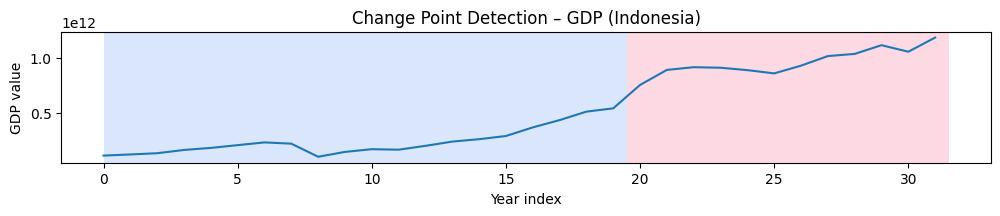

[2010]


In [69]:
data = df[["year", "gdp"]].dropna(subset=["gdp"]).reset_index(drop=True)
X = data[["gdp"]].values
years = data["year"].values 

algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)
rpt.display(X, result)
plt.title("Change Point Detection – GDP (Indonesia)")
plt.xlabel("Year index")
plt.ylabel("GDP value")
plt.show()
change_years = [int(years[i]) for i in result[:-1] if i < len(years)]
print(f"{change_years}")

##### Result
A single change point was detected around **2010**, indicating a shift in Indonesia’s GDP growth pattern.

##### Comment
Before 2010, Indonesia’s GDP grew **steadily but moderately**, reflecting the country’s long-term recovery  
from the **1997–1998 Asian Financial Crisis** and structural reforms in the early 2000s.  
After 2010, growth accelerated significantly, suggesting **stronger domestic demand, rising investment,  
and improved fiscal management**.  
This transition aligns with Indonesia’s **post-crisis economic consolidation and expansion policies**,  
which promoted sustained GDP growth throughout the 2010s (**World Bank, 2012; IMF, 2013**).